# Simple MNIST convnet

This example is based on the [Keras documentation](https://keras.io/examples/vision/mnist_convnet/).

In [7]:
from scipy.stats import entropy
from tensorflow import keras
from tensorflow.keras import layers
import matplotlib.pyplot as plt
import numpy as np

num_classes = 10
input_shape = (28, 28, 1)

(x_train, y_train), (x_test, y_test) = keras.datasets.mnist.load_data()

x_train = x_train.astype("float32") / 255
x_test = x_test.astype("float32") / 255

In [8]:
x_train = np.expand_dims(x_train, -1)
x_test = np.expand_dims(x_test, -1)

print("x_train shape:", x_train.shape)
print(x_train.shape[0], "train samples")
print(x_test.shape[0], "test samples")

y_train = keras.utils.to_categorical(y_train, num_classes)
y_test = keras.utils.to_categorical(y_test, num_classes)

x_train shape: (60000, 28, 28, 1)
60000 train samples
10000 test samples


In [9]:
model = keras.Sequential(
    [
        keras.Input(shape=input_shape),
        layers.Conv2D(32, kernel_size=(3, 3), activation="relu"),
        layers.MaxPooling2D(pool_size=(2, 2)),
        layers.Conv2D(64, kernel_size=(3, 3), activation="relu"),
        layers.MaxPooling2D(pool_size=(2, 2)),
        layers.Flatten(),
        layers.Dropout(0.5),
        layers.Dense(num_classes, activation="softmax"),
    ]
)

model.summary()

Model: "sequential_1"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
conv2d_2 (Conv2D)            (None, 26, 26, 32)        320       
_________________________________________________________________
max_pooling2d_2 (MaxPooling2 (None, 13, 13, 32)        0         
_________________________________________________________________
conv2d_3 (Conv2D)            (None, 11, 11, 64)        18496     
_________________________________________________________________
max_pooling2d_3 (MaxPooling2 (None, 5, 5, 64)          0         
_________________________________________________________________
flatten_1 (Flatten)          (None, 1600)              0         
_________________________________________________________________
dropout_1 (Dropout)          (None, 1600)              0         
_________________________________________________________________
dense_1 (Dense)              (None, 10)               

In [17]:
model.compile(loss="categorical_crossentropy", optimizer="adam", metrics=["accuracy"])
model.fit(x_train, y_train, batch_size=128, epochs=1, validation_split=0.1, verbose=0)

In [18]:
score = model.evaluate(x_test, y_test, verbose=0)
print("Test loss:", score[0])
print("Test accuracy:", score[1])

p_test = np.array(model(x_test))

Test loss: 0.03050306625664234
Test accuracy: 0.9894000291824341


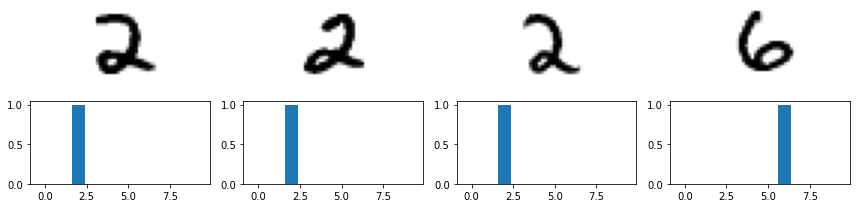

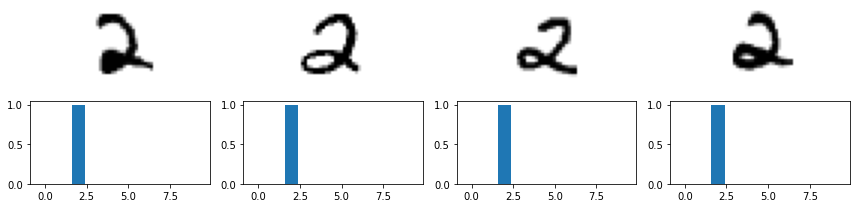

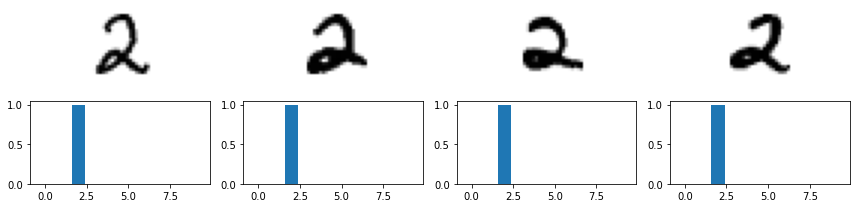

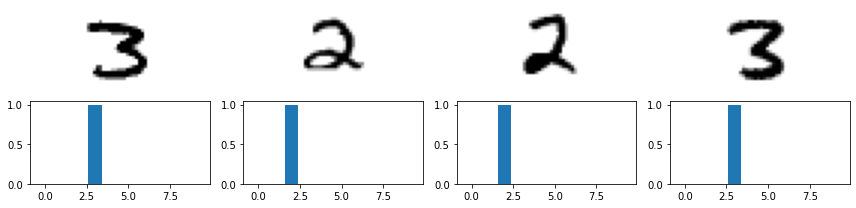

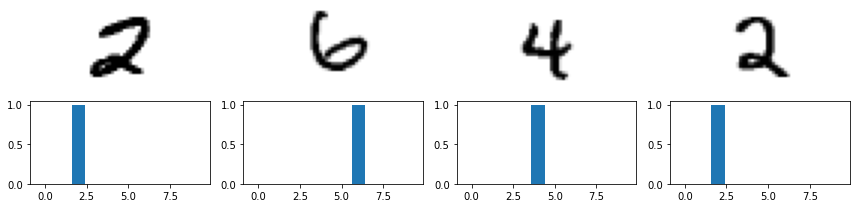

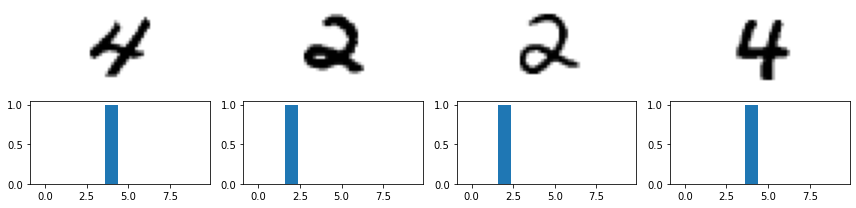

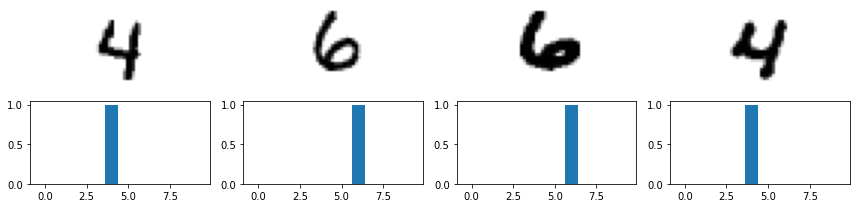

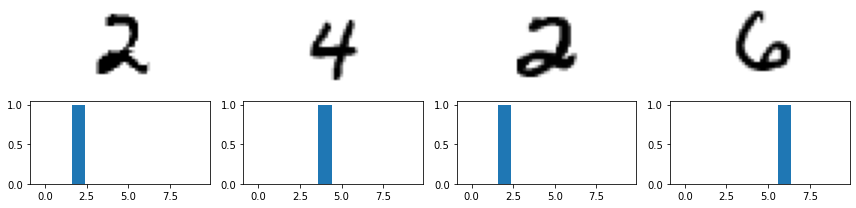

In [32]:
def find_indices_by_sorted_entropy(data, ascend):
    return np.argsort(entropy(data, axis=-1))[::1 if ascend else -1]

def plot(ascend=False):
    nrows = 8
    ncols = 4

    for z in range(nrows):
        fig, axs = plt.subplots(nrows=2, ncols=ncols, figsize=(12,3))
        uncertain_indices = find_indices_by_sorted_entropy(p_test, ascend)
        for i, (upper, lower) in enumerate(axs.T):
            upper.imshow(x_test[uncertain_indices][z*nrows+i], cmap="binary")
            upper.axis("off")
            lower.bar(np.arange(10), p_test[uncertain_indices][z*nrows+i])
        plt.tight_layout()
    
plot(True)

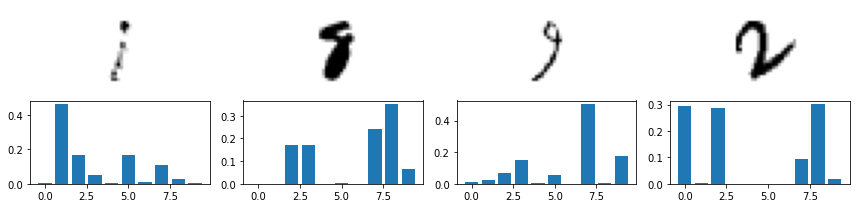

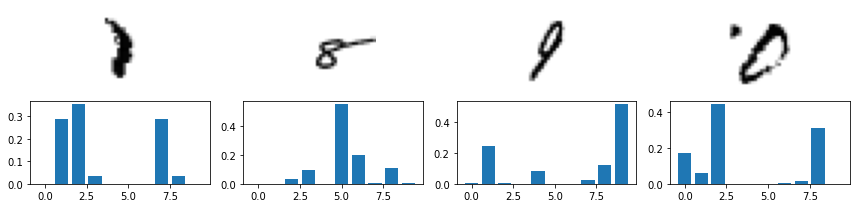

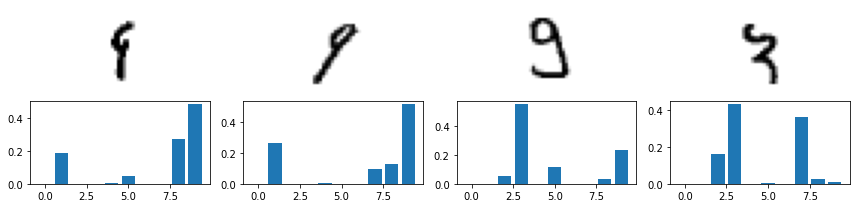

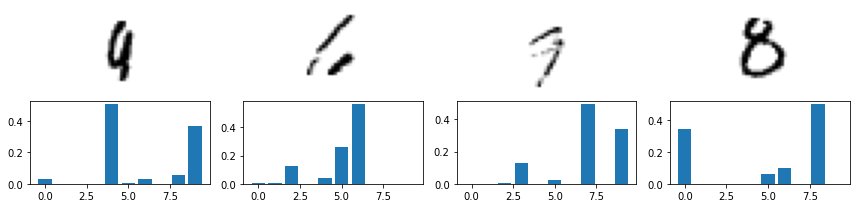

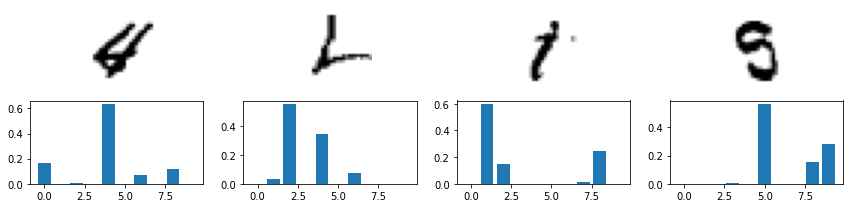

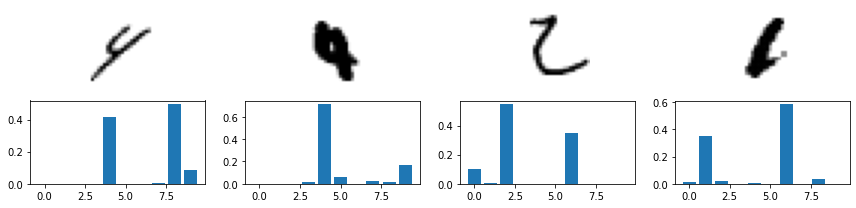

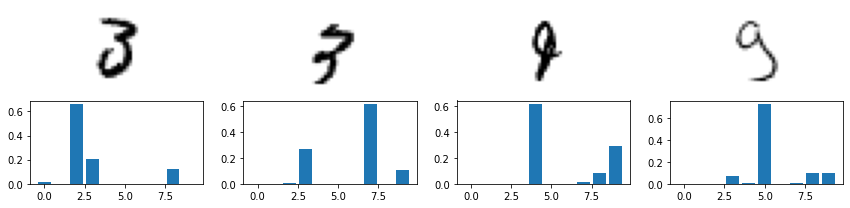

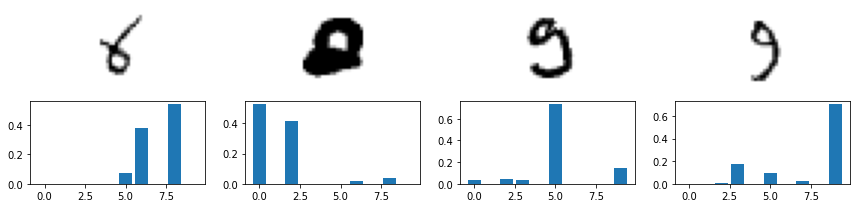

In [33]:
plot(False)